# Step 4 — Model Training

**What this notebook does:** Merges all three data sources (enriched workflow + telemetry + reagent), trains binary classifiers (LogReg, RF, HGB), calibrates probabilities, and exports the final model artifact.

**Inputs (from Steps 1–3):**
- `../data/enriched/workflow_logs_priority_queue.csv`
- `../data/raw/telemetry_logs.csv`
- `../data/raw/reagent_logs.csv`

**Outputs:**
- `../models/lab_delay_model_v3.pkl`
- `../models/thresholds.csv`
- `../results/family_importance_perm_v3.csv`
- `../results/global_importance_perm_v3.csv`

**Run order:** Run after Steps 1, 2, and 3 (notebooks 01, 02, 03).

# Roche Lab Delay Risk Predictor — Model Training (v3)
This notebook trains and selects the best classification model to predict delay risk (is_delayed),
then calibrates probabilities and exports the final model artifact for Streamlit deployment.

## Notebook overview

This notebook trains and exports the **v3 Delay Risk Predictor** model.

**Pipeline at a glance**
1. Load workflow + telemetry + reagent logs
2. Aggregate telemetry into per-experiment features
3. Merge reagent batch IDs onto the training data
4. Build a delay label using a configurable threshold
5. Define features and prevent leakage
6. Train the model pipeline + evaluate
7. Calibrate probabilities (optional but recommended)
8. Export the final `pkl` artifact for the Streamlit app

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score, confusion_matrix
)

RANDOM_STATE = 42
DELAY_MIN_THRESHOLD = 30  # minutes -> defines the binary label

DATA_DIR = Path("..")
WORKFLOW_PATH  = DATA_DIR / "data" / "enriched" / "workflow_logs_priority_queue.csv"
TELEMETRY_PATH = DATA_DIR / "data" / "raw" / "telemetry_logs.csv"
REAGENT_PATH   = DATA_DIR / "data" / "raw" / "reagent_logs.csv"

MODEL_OUT = DATA_DIR / "models" / "lab_delay_model_v3.pkl"
THR_OUT   = DATA_DIR / "models" / "thresholds.csv"

IMP_FAMILY_OUT = DATA_DIR / "results" / "family_importance_perm_v3.csv"
IMP_GLOBAL_OUT = DATA_DIR / "results" / "global_importance_perm_v3.csv"

## Data inputs and file expectations

This training notebook expects the following input files:

- **Workflow logs** (enriched): experiment-level records with priority + queue features
- **Telemetry logs**: time-series signals keyed by `experiment_id`
- **Reagent logs**: reagent batch assignments per experiment (includes 3 "bad batches")
- **Threshold config** (optional): a CSV that overrides the default delay threshold

If any required file is missing, the notebook will stop early.

In [2]:
assert WORKFLOW_PATH.exists(), f"Missing {WORKFLOW_PATH}"
assert TELEMETRY_PATH.exists(), f"Missing {TELEMETRY_PATH}"
assert REAGENT_PATH.exists(),  f"Missing {REAGENT_PATH}"

df_work = pd.read_csv(WORKFLOW_PATH)
df_tel  = pd.read_csv(TELEMETRY_PATH)
df_rea  = pd.read_csv(REAGENT_PATH)

print("workflow:", df_work.shape, "| telemetry:", df_tel.shape, "| reagent:", df_rea.shape)
df_work.head()

workflow: (350000, 25) | telemetry: (350000, 5) | reagent: (350000, 3)


,experiment_id,experiment_type,instrument_type,instrument_id,scientist_workload,scientist_experience_level,lab_occupancy_level,expected_duration,booking_time,actual_duration,...,queue_wait_min,queue_length,hour_of_day,day_of_week,is_weekend,days_since_start,stress_index,duration_to_queue_ratio,instrument_cumulative_hours,instrument_recent_failure_rate
0,EXP_000000,Pilot,Incubator,Incubator_04,3,Junior,59,90,2024-01-01 00:18:04,98.944742,...,0.0,0,0,0,0,0.000000,177,90.0,1.50,0.0
1,EXP_000001,QC,Spectrometer,Spectrometer_04,4,Mid,54,45,2024-01-01 00:44:22,45.895662,...,0.0,0,0,0,0,0.018264,216,45.0,0.75,0.0
2,EXP_000002,QC,HPLC,HPLC_03,1,Senior,43,45,2024-01-01 01:05:07,45.618095,...,0.0,0,1,0,0,0.032674,43,45.0,0.75,0.0
3,EXP_000003,QC,Spectrometer,Spectrometer_01,5,Senior,51,45,2024-01-01 01:21:09,63.556023,...,0.0,0,1,0,0,0.043808,255,45.0,0.75,0.0
4,EXP_000004,Screening,PCR,PCR_00,6,Senior,81,30,2024-01-01 01:42:56,70.318977,...,0.0,0,1,0,0,0.058935,486,30.0,0.50,0.0


## Telemetry cleaning and aggregation

Telemetry is cleaned and converted into numeric/time formats, then aggregated **per `experiment_id`**.

Typical aggregated signals:
- mean / max / std of temperature (or other sensor values)
- record count (telemetry coverage)
- time span between first and last record (data completeness proxy)

These aggregated features are later merged into the workflow table for model training.

In [3]:
df_tel["timestamp"] = pd.to_datetime(df_tel.get("timestamp", pd.NaT), errors="coerce")
df_tel["ambient_temp"] = pd.to_numeric(df_tel.get("ambient_temp", np.nan), errors="coerce")

tel_agg = df_tel.groupby("experiment_id").agg(
    ambient_temp=("ambient_temp", "mean"),
    ambient_temp_max=("ambient_temp", "max"),
    ambient_temp_std=("ambient_temp", "std"),
    telemetry_records=("timestamp", "count"),
    tel_time_span_sec=("timestamp", lambda s: (s.max() - s.min()).total_seconds() if s.notna().any() else 0.0),
).reset_index()

tel_agg["ambient_temp_std"] = pd.to_numeric(tel_agg["ambient_temp_std"], errors="coerce").fillna(0.0)

df = df_work.merge(tel_agg, on="experiment_id", how="left")

for c in ["ambient_temp","ambient_temp_max","ambient_temp_std","telemetry_records","tel_time_span_sec"]:
    df[c] = pd.to_numeric(df.get(c, 0.0), errors="coerce").fillna(0.0)

df.head()

,experiment_id,experiment_type,instrument_type,instrument_id,scientist_workload,scientist_experience_level,lab_occupancy_level,expected_duration,booking_time,actual_duration,...,days_since_start,stress_index,duration_to_queue_ratio,instrument_cumulative_hours,instrument_recent_failure_rate,ambient_temp,ambient_temp_max,ambient_temp_std,telemetry_records,tel_time_span_sec
0,EXP_000000,Pilot,Incubator,Incubator_04,3,Junior,59,90,2024-01-01 00:18:04,98.944742,...,0.000000,177,90.0,1.50,0.0,19.592974,19.592974,0.0,1,0.0
1,EXP_000001,QC,Spectrometer,Spectrometer_04,4,Mid,54,45,2024-01-01 00:44:22,45.895662,...,0.018264,216,45.0,0.75,0.0,26.231117,26.231117,0.0,1,0.0
2,EXP_000002,QC,HPLC,HPLC_03,1,Senior,43,45,2024-01-01 01:05:07,45.618095,...,0.032674,43,45.0,0.75,0.0,17.779599,17.779599,0.0,1,0.0
3,EXP_000003,QC,Spectrometer,Spectrometer_01,5,Senior,51,45,2024-01-01 01:21:09,63.556023,...,0.043808,255,45.0,0.75,0.0,28.754803,28.754803,0.0,1,0.0
4,EXP_000004,Screening,PCR,PCR_00,6,Senior,81,30,2024-01-01 01:42:56,70.318977,...,0.058935,486,30.0,0.50,0.0,20.927409,20.927409,0.0,1,0.0


## Reagent data merge

We merge `reagent_batch_id` from the reagent logs onto each experiment.
Three of the 50 batches are intentionally "bad batches" with 5× failure risk.
This categorical feature is expected to be an important delay predictor.

In [4]:
# =========================================================
# Reagent merge
# =========================================================
df = df.merge(
    df_rea[["experiment_id", "reagent_batch_id"]].drop_duplicates("experiment_id"),
    on="experiment_id", how="left"
)
df["reagent_batch_id"] = df["reagent_batch_id"].fillna("UNKNOWN")

print("After reagent merge:", df.shape)
print("Unique batches:", df["reagent_batch_id"].nunique())
df.head()

After reagent merge: (350000, 31)
Unique batches: 50


,experiment_id,experiment_type,instrument_type,instrument_id,scientist_workload,scientist_experience_level,lab_occupancy_level,expected_duration,booking_time,actual_duration,...,stress_index,duration_to_queue_ratio,instrument_cumulative_hours,instrument_recent_failure_rate,ambient_temp,ambient_temp_max,ambient_temp_std,telemetry_records,tel_time_span_sec,reagent_batch_id
0,EXP_000000,Pilot,Incubator,Incubator_04,3,Junior,59,90,2024-01-01 00:18:04,98.944742,...,177,90.0,1.50,0.0,19.592974,19.592974,0.0,1,0.0,BATCH_013
1,EXP_000001,QC,Spectrometer,Spectrometer_04,4,Mid,54,45,2024-01-01 00:44:22,45.895662,...,216,45.0,0.75,0.0,26.231117,26.231117,0.0,1,0.0,BATCH_016
2,EXP_000002,QC,HPLC,HPLC_03,1,Senior,43,45,2024-01-01 01:05:07,45.618095,...,43,45.0,0.75,0.0,17.779599,17.779599,0.0,1,0.0,BATCH_005
3,EXP_000003,QC,Spectrometer,Spectrometer_01,5,Senior,51,45,2024-01-01 01:21:09,63.556023,...,255,45.0,0.75,0.0,28.754803,28.754803,0.0,1,0.0,BATCH_046
4,EXP_000004,Screening,PCR,PCR_00,6,Senior,81,30,2024-01-01 01:42:56,70.318977,...,486,30.0,0.50,0.0,20.927409,20.927409,0.0,1,0.0,BATCH_034


## Target definition (label)

We train a classifier that predicts whether an experiment will be **delayed**.

- Raw target: `delay` (minutes)
- Binary label: `is_delayed = delay >= delay_min_threshold`

The delay threshold can be configured so that “delay” matches operational policy (e.g., 30 minutes).

In [5]:
assert "delay" in df.columns, "workflow must contain 'delay' column to build label."

df["delay"] = pd.to_numeric(df["delay"], errors="coerce").fillna(0.0)
df["is_delayed"] = (df["delay"] >= float(DELAY_MIN_THRESHOLD)).astype(int)

print(df["is_delayed"].value_counts(dropna=False))

is_delayed
0    182395
1    167605
Name: count, dtype: int64


## Leakage prevention (critical)

To ensure the model generalizes, we must remove columns that directly reveal the target
or are only known **after** execution.

Examples:
- `delay` (the target itself)
- `actual_duration` (post-run measurement)
- `is_delayed` (derived label)

Keeping any leakage columns will inflate validation scores and break real-world performance.

In [6]:
LEAKAGE_COLS = {"delay", "actual_duration", "is_delayed"}
ID_COLS = {"experiment_id"}

# machine_failure: run-time event (not known at booking time) → leakage
# incident_type: assigned post-run based on delay > 30 → direct target leakage
DROP_COLS = LEAKAGE_COLS | ID_COLS | {"booking_time", "machine_failure", "incident_type"}

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df["is_delayed"].copy()

print("X shape:", X.shape, "y mean:", y.mean())

X shape: (350000, 25) y mean: 0.47887142857142856


## Train/validation/test split strategy

We prepare the dataset for training by sorting and splitting into train/validation/test sets.

Best practice for operational models:
- Prefer **time-aware** splits (train on past, validate on future)
- Avoid leakage from random shuffling when temporal drift exists

This improves how well evaluation reflects real deployment conditions.

In [7]:
df_sorted = df.copy()
df_sorted["booking_time"] = pd.to_datetime(df_sorted["booking_time"], errors="coerce")

if df_sorted["booking_time"].notna().mean() >= 0.80:
    df_sorted = df_sorted.sort_values("booking_time").reset_index(drop=True)
    n = len(df_sorted)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    train_idx = df_sorted.index[:n_train]
    val_idx   = df_sorted.index[n_train:n_train+n_val]
    test_idx  = df_sorted.index[n_train+n_val:]

    X_train = df_sorted.loc[train_idx, feature_cols].copy()
    y_train = df_sorted.loc[train_idx, "is_delayed"].copy()
    X_val   = df_sorted.loc[val_idx, feature_cols].copy()
    y_val   = df_sorted.loc[val_idx, "is_delayed"].copy()
    X_test  = df_sorted.loc[test_idx, feature_cols].copy()
    y_test  = df_sorted.loc[test_idx, "is_delayed"].copy()
    print("[split] time-based split used")
else:
    X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp)
    print("[split] stratified random split used")

print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)

[split] time-based split used
train/val/test: (244999, 25) (52500, 25) (52501, 25)


## Feature typing and preprocessing

We separate features into:
- **Numeric columns**: imputed using mean/median
- **Categorical columns**: imputed using most-frequent/constant and encoded via one-hot

A consistent preprocessing pipeline is essential because:
- training and inference must apply the **same transforms**
- missing values and new categories must be handled safely

In [8]:
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print("num:", len(num_cols), "cat:", len(cat_cols))

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

num: 19 cat: 6


In [9]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# ---- sanity checks (fail fast)
required_vars = ["preprocess", "X_train", "y_train", "X_val", "y_val"]
for v in required_vars:
    if v not in globals():
        raise NameError(f"[cell10] Missing required variable: {v}. Define it in previous cells first.")

RANDOM_STATE = 42
PRIMARY_METRIC = "pr_auc"

def eval_binary(y_true, proba, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    y_pred = (proba >= thr).astype(int)
    uniq = np.unique(y_true)
    return {
        "roc_auc": roc_auc_score(y_true, proba) if len(uniq) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, proba) if len(uniq) > 1 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

# ✅ pickle-safe dense converter (named function, NOT lambda)
def sparse_to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

to_dense = FunctionTransformer(sparse_to_dense, accept_sparse=True)

# ---- candidate pipelines
candidates = {
    "logreg_l2": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=2000, solver="lbfgs")),
    ]),
    "rf": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE
        )),
    ]),
    "hgb": Pipeline([
        ("preprocess", preprocess),
        ("to_dense", to_dense),  # ✅ dense conversion only here
        ("model", HistGradientBoostingClassifier(
            max_depth=6,
            learning_rate=0.06,
            max_iter=350,
            random_state=RANDOM_STATE
        )),
    ]),
}

rows = []
fitted = {}

for name, pipe in candidates.items():
    pipe.fit(X_train, y_train)
    p_val = pipe.predict_proba(X_val)[:, 1]
    m = eval_binary(y_val, p_val, thr=0.5)
    m["model"] = name
    rows.append(m)
    fitted[name] = pipe
    print(f"[ok] {name} fitted | val {PRIMARY_METRIC}={m[PRIMARY_METRIC]:.4f}")

score_df = pd.DataFrame(rows).sort_values(PRIMARY_METRIC, ascending=False)
print("\n=== VALIDATION SCORES ===")
print(score_df)

best_name = score_df.iloc[0]["model"]
best_pipe = fitted[best_name]
print(f"\n[select] best model = {best_name} by {PRIMARY_METRIC}")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

[ok] logreg_l2 fitted | val pr_auc=0.8664
[ok] rf fitted | val pr_auc=0.8708
[ok] hgb fitted | val pr_auc=0.8817

=== VALIDATION SCORES ===
    roc_auc    pr_auc        f1  precision    recall      model
2  0.860639  0.881740  0.792035   0.777865  0.806730        hgb
1  0.852336  0.870810  0.781204   0.780479  0.781930         rf
0  0.842813  0.866443  0.775484   0.788816  0.762595  logreg_l2

[select] best model = hgb by pr_auc


## Probability calibration (recommended)

The raw model score is not always a well-calibrated probability.
Calibration improves decision-making when you rely on thresholds (green/amber/red).

Common methods:
- **Sigmoid (Platt scaling)**: stable for smaller validation sets
- **Isotonic**: more flexible but needs more data to avoid overfitting

After calibration, `predict_proba` is more reliable for operational policies.

In [10]:
CAL_METHOD = "sigmoid"  # safer; use "isotonic" if you have a large validation set

calibrated_model = CalibratedClassifierCV(best_pipe, method=CAL_METHOD, cv="prefit")
calibrated_model.fit(X_val, y_val)

p_val_cal = calibrated_model.predict_proba(X_val)[:, 1]
print("[calibrated] val metrics @0.5:", eval_binary(y_val, p_val_cal, thr=0.5))

/opt/homebrew/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/opt/homebrew/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/opt/homebrew/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: invalid value encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)


[calibrated] val metrics @0.5: {'roc_auc': 0.8606391922647973, 'pr_auc': 0.8817395726737421, 'f1': 0.7923330840916966, 'precision': 0.7775431312191281, 'recall': 0.807696597880647}


## Evaluation on validation set

We evaluate the calibrated model using predicted probabilities on the validation set.

Typical checks:
- discrimination (e.g., ROC-AUC)
- threshold-based performance (precision/recall at policy thresholds)
- calibration sanity (probabilities align with observed rates)

This step ensures the model is actionable for operational triage.

In [11]:
p_val = calibrated_model.predict_proba(X_val)[:, 1]

thr_grid = np.linspace(0.05, 0.80, 16)
best_thr = 0.5
best_f1 = -1.0

for t in thr_grid:
    f1 = eval_binary(y_val, p_val, thr=float(t))["f1"]
    if f1 > best_f1:
        best_f1, best_thr = f1, float(t)

print(f"[threshold] best f1={best_f1:.4f} at thr={best_thr:.2f}")

pd.DataFrame({
    "delay_min_threshold": [DELAY_MIN_THRESHOLD],
    "risk_threshold": [best_thr],
}).to_csv(THR_OUT, index=False)

print("[saved]", THR_OUT.resolve())

[threshold] best f1=0.7964 at thr=0.40
[saved] /Users/marianasaca/Downloads/roche-capstone/models/thresholds.csv


In [12]:
p_test = calibrated_model.predict_proba(X_test)[:, 1]
test_metrics = eval_binary(y_test, p_test, thr=best_thr)
print("[test metrics]", test_metrics)

cm = confusion_matrix(y_test, (p_test >= best_thr).astype(int))
print("\nconfusion matrix @ thr", best_thr)
print(cm)

[test metrics] {'roc_auc': 0.8630042886063488, 'pr_auc': 0.8828647825020994, 'f1': 0.7971377207515246, 'precision': 0.7554115446285409, 'recall': 0.843743004253414}

confusion matrix @ thr 0.4
[[18377  7322]
 [ 4188 22614]]


## Model Evaluation Visualisations

PR curve and calibration plot for the final calibrated model on the test set.

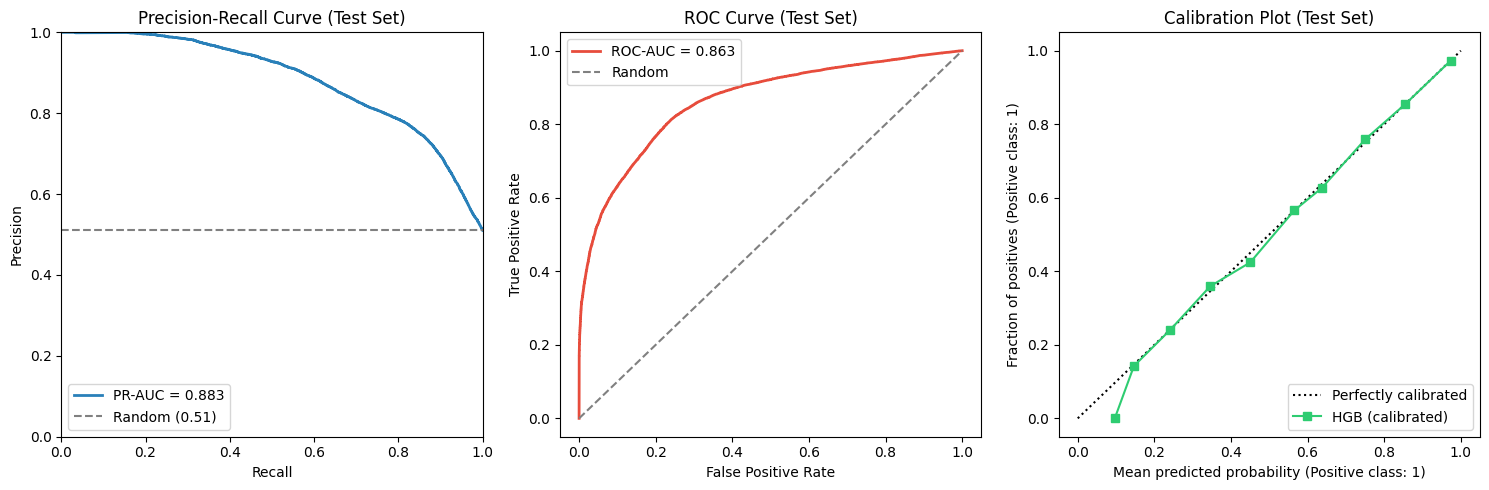

In [13]:
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

p_test = calibrated_model.predict_proba(X_test)[:, 1]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# ── 1. PR Curve ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
prec, rec, _ = precision_recall_curve(y_test, p_test)
pr_auc_val = average_precision_score(y_test, p_test)
ax1.plot(rec, prec, color='#2980b9', lw=2, label=f'PR-AUC = {pr_auc_val:.3f}')
ax1.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Random ({y_test.mean():.2f})')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve (Test Set)')
ax1.legend()
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

# ── 2. ROC Curve ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_test, p_test)
roc_val = roc_auc_score(y_test, p_test)
ax2.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC-AUC = {roc_val:.3f}')
ax2.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve (Test Set)')
ax2.legend()

# ── 3. Calibration Plot ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, ax=ax3,
                                     name='HGB (calibrated)', color='#2ecc71')
ax3.set_title('Calibration Plot (Test Set)')

plt.tight_layout()
plt.show()

## Export artifact for the Streamlit app

Finally, we export the trained (and calibrated) pipeline as a `.pkl` file.

This artifact is loaded by the Streamlit app via `joblib.load(...)` and must include:
- preprocessing (imputation + encoding)
- the trained estimator
- calibration wrapper (if used)

Versioning tip:
- keep a clear naming convention (e.g., `lab_delay_model_v3.pkl`)
- store the training config/threshold alongside the model for traceability

In [14]:
from sklearn.inspection import permutation_importance

# Save model
joblib.dump(calibrated_model, MODEL_OUT)
print("[saved model]", MODEL_OUT.resolve())

# Reload sanity check
m2 = joblib.load(MODEL_OUT)
print("reload ok | proba[0] =", m2.predict_proba(X_test.head(1))[:, 1][0])

# ---- Feature importance (global) ----
X_imp = X_test.sample(n=min(2000, len(X_test)), random_state=42)
y_imp = y_test.loc[X_imp.index]

r = permutation_importance(calibrated_model, X_imp, y_imp,
                           n_repeats=5, random_state=42,
                           scoring="average_precision")

imp_global = pd.DataFrame({
    "feature": feature_cols,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

imp_global.to_csv(IMP_GLOBAL_OUT, index=False)
print("[saved]", IMP_GLOBAL_OUT.resolve())

# ---- Family importance ----
FAMILY_RULES = {
    "Device Reliability": ["instrument_type", "instrument_id", "ambient_temp", "telemetry", "tel_", "instrument_health", "instrument_cumulative", "instrument_recent"],
    "Queue & Scheduling": ["occupancy", "workload", "hour_of_day", "stress_index", "booking_time", "queue_", "priority", "day_of_week", "is_weekend", "days_since_start", "duration_to_queue"],
    "Workflow Complexity": ["experiment_type", "expected_duration", "experience_level"],
    "Reagents & Supply": ["reagent", "batch", "stock", "inventory", "reagent_batch_id"],
}

def assign_family(feat):
    f = feat.lower()
    for fam, keys in FAMILY_RULES.items():
        if any(k in f for k in keys):
            return fam
    return "Other"

imp_global["family"] = imp_global["feature"].apply(assign_family)
fam_imp = imp_global.groupby("family")["importance"].sum().sort_values(ascending=False).reset_index()
fam_imp.to_csv(IMP_FAMILY_OUT, index=False)
print("[saved]", IMP_FAMILY_OUT.resolve())

print("\n=== Feature Importance (top 15) ===")
print(imp_global.head(15).to_string(index=False))

[saved model] /Users/marianasaca/Downloads/roche-capstone/models/lab_delay_model_v3.pkl
reload ok | proba[0] = 0.8296931568815036
[saved] /Users/marianasaca/Downloads/roche-capstone/results/global_importance_perm_v3.csv
[saved] /Users/marianasaca/Downloads/roche-capstone/results/family_importance_perm_v3.csv

=== Feature Importance (top 15) ===
                       feature  importance              family
           lab_occupancy_level    0.152560  Queue & Scheduling
              reagent_batch_id    0.142186   Reagents & Supply
                      priority    0.044897  Queue & Scheduling
               instrument_type    0.024709  Device Reliability
instrument_recent_failure_rate    0.002645  Device Reliability
                  ambient_temp    0.002307  Device Reliability
       duration_to_queue_ratio    0.002262  Queue & Scheduling
                 instrument_id    0.000172  Device Reliability
                   hour_of_day    0.000064  Queue & Scheduling
               experime